<a href="https://colab.research.google.com/github/ZakParkinson04/Using-Chest-X-rays-to-diagnose-diseases-and-anomalies-an-explainable-AI-Model-for-medical-Diagnosis/blob/main/final_evaluation_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Model Evaluation Notebook



In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Install Grad-CAM





In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 18.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=aa7a6d76e2a3e3838378a1ab771996c94d065afec9935d4b44c7133f8bbe9731
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


## Import Libraries




In [ ]:
import os
import shutil

# Fix for ImportError: cannot import name 'equal_valued' from 'sympy.core.numbers'
# The previous fix to downgrade sympy caused a new incompatibility with torch.
# This re-installs a version of sympy compatible with both torch and grad-cam.
!pip uninstall sympy -y
!pip install sympy==1.14.0

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F


from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm import tqdm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget



Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 14.7 MB/s eta 0:00:00


In [ ]:
import zipfile
import pathlib
from pathlib import Path

## Set Project Paths



In [ ]:
Project_Direct = "/content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support"
Zip_Path = os.path.join(Project_Direct, "data/processed/Split.zip")


Output_Direct = os.path.join(Project_Direct, "outputs")
Evaluation_Direct = os.path.join(Output_Direct, "Results")

os.makedirs(Evaluation_Direct, exist_ok=True)

print("Evaluation output folder:", Evaluation_Direct)

Evaluation output folder: /content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support/outputs/Results


In [ ]:
Local_Data_Dir = "/content/chest_xray_split"
Local_Zip_Path = "/content/chest_xray_split_Zipped.zip"

if Path(Local_Data_Dir).exists():
  print("Removing incomplete existing directory to force re-extraction.")
  shutil.rmtree(Local_Data_Dir)

print("Copying Zip from Drive to Colab.")
shutil.copy2(Zip_Path, Local_Zip_Path)

print("Unzipping Data.")
with zipfile.ZipFile(Local_Zip_Path, "r") as zip_ref:
  zip_ref.extractall(Local_Data_Dir)

print("Data unzipped at:", Local_Data_Dir)
print("Contents of extracted folder:", os.listdir(Local_Data_Dir))

if "split_updated" in os.listdir(Local_Data_Dir):
    Local_Data_Dir = os.path.join(Local_Data_Dir, "split_updated")

TRAIN_DIR = os.path.join(Local_Data_Dir, "train")
VAL_DIR = os.path.join(Local_Data_Dir, "val")
TEST_DIR = os.path.join(Local_Data_Dir, "test")

print("\nTrain exists:", Path(TRAIN_DIR).exists())
print("Val exists:", Path(VAL_DIR).exists())
print("Test exists:", Path(TEST_DIR).exists())

Removing incomplete existing directory to force re-extraction.
Copying Zip from Drive to Colab.
Unzipping Data.
Data unzipped at: /content/chest_xray_split
Contents of extracted folder: ['split_updated']

Train exists: True
Val exists: True
Test exists: True


## Choose the Model to Evaluate

This notebook evaluates one model at a time.

In [ ]:
Model_Type = "densenet121"
Model_Name = "DenseNet121"

#Model_Path = os.path.join(
 #   Output_Direct,
  #  "models",
   # "densenet",
    #"FineTuned_DenseNet_Final.pth"
#)


#For ResNet50, use:
Model_Type = "resnet50"
Model_Name = "ResNet50_Best"
Model_Path = os.path.join(Output_Direct, "models", "resnet", "Benchmark_ResNet.pth")

print("Model name:", Model_Name)
print("Model type:", Model_Type)
print("Model weights:", Model_Path)
print("Weights file exists:", os.path.exists(Model_Path))




Model name: ResNet50_Best
Model type: resnet50
Model weights: /content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support/outputs/models/resnet/Benchmark_ResNet.pth
Weights file exists: True


## General Settings

The image size and batch size are kept the same as the training notebook.
The device will use GPU if Colab has one available.




In [ ]:
Image_Size = 224
Batch_Size = 64

Device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", Device)




Device: cuda


## Preprocessing for Evaluation

The test set should not use random augmentation.

This preprocessing matches the training notebook:

- resize images to 224 x 224
- convert grayscale X-rays to 3 channels
- convert images into tensors
- normalise using ImageNet mean and standard deviation




In [ ]:
Test_Transform = transforms.Compose([
    transforms.Resize((Image_Size, Image_Size)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])




## Load the Dataset

The processed dataset is copied from Google Drive into Colab's local storage.
This usually makes the evaluation run faster.

`ImageFolder` reads the folder names as class labels.




In [ ]:
Local_Data_Dir = "/content/chest_xray_final_eval"
Data_Dir = "/content/chest_xray_split/split_updated" # Path where data was unzipped in previous cell LA3ond5FT8Ea

if os.path.exists(Local_Data_Dir):
    shutil.rmtree(Local_Data_Dir)

shutil.copytree(Data_Dir, Local_Data_Dir)

Train_Dir = os.path.join(Local_Data_Dir, "train")
Val_Dir = os.path.join(Local_Data_Dir, "val")
Test_Dir = os.path.join(Local_Data_Dir, "test")

Train_Data = datasets.ImageFolder(Train_Dir, transform=Test_Transform)
Val_Data = datasets.ImageFolder(Val_Dir, transform=Test_Transform)
Test_Data = datasets.ImageFolder(Test_Dir, transform=Test_Transform)

Class_Names = Test_Data.classes
Num_Classes = len(Class_Names)

Test_Load = DataLoader(
    Test_Data,
    batch_size=Batch_Size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class names:", Class_Names)
print("Class index order:", Test_Data.class_to_idx)
print("Training images:", len(Train_Data))
print("Validation images:", len(Val_Data))
print("Test images:", len(Test_Data))


Class names: ['COVID', 'Lung Cancer', 'Normal Split', 'Pneumonia', 'Tuberculosis']
Class index order: {'COVID': 0, 'Lung Cancer': 1, 'Normal Split': 2, 'Pneumonia': 3, 'Tuberculosis': 4}
Training images: 4649
Validation images: 996
Test images: 997


## Plot Dataset Distribution

This graph shows how many images are in each class for train, validation,
and test data.




,Split,Class,Images
0,Train,COVID,1046
1,Train,Lung Cancer,1042
2,Train,Normal Split,1080
3,Train,Pneumonia,993
4,Train,Tuberculosis,488
5,Validation,COVID,224
6,Validation,Lung Cancer,223
7,Validation,Normal Split,231
8,Validation,Pneumonia,213
9,Validation,Tuberculosis,105


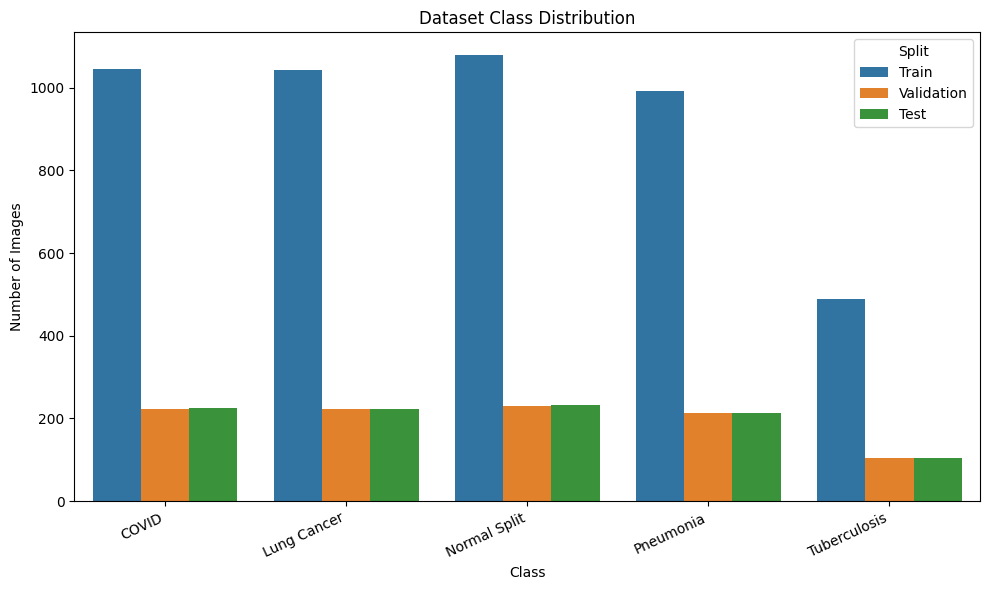

In [ ]:
Distribution_Rows = []

for Split_Name, Dataset in [
    ("Train", Train_Data),
    ("Validation", Val_Data),
    ("Test", Test_Data)
]:
    Labels = [Label for _, Label in Dataset.samples]
    Counts = pd.Series(Labels).value_counts().sort_index()

    for Class_Index, Count in Counts.items():
        Distribution_Rows.append({
            "Split": Split_Name,
            "Class": Class_Names[Class_Index],
            "Images": Count
        })

Distribution_DF = pd.DataFrame(Distribution_Rows)
display(Distribution_DF)

Distribution_DF.to_csv(
    os.path.join(Evaluation_Direct, "dataset_distribution.csv"),
    index=False
)

plt.figure(figsize=(10, 6))
sns.barplot(data=Distribution_DF, x="Class", y="Images", hue="Split")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, "dataset_distribution.png"), dpi=300)
plt.show()




## Recreate the Model Architecture

Saved weights do not contain the full model structure.
Therefore, the same architecture must be created first.

The final layer is changed so the model predicts the number of classes in
this dataset.




In [ ]:
def Create_DenseNet121_Model(Num_Classes, Pretrained = True):
  weights = models.DenseNet121_Weights.DEFAULT if Pretrained else None
  Dense_model = models.densenet121(weights=weights)

  in_features = Dense_model.classifier.in_features
  Dense_model.classifier = nn.Sequential(
      nn.Dropout(p=0.4),
      nn.Linear(in_features, 256),
      nn.ReLU(),
      nn.Dropout(p=0.3),
      nn.Linear(256, Num_Classes)
  )

  return Dense_model


def Create_ResNet50_Model(Num_Classes, Pretrained = True):
    weights = models.ResNet50_Weights.DEFAULT if Pretrained else None
    Res_model = models.resnet50(weights=weights)

    in_features = Res_model.fc.in_features
    Res_model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, Num_Classes)
  )
    return Res_model


if Model_Type == "densenet121":
    Model = Create_DenseNet121_Model(Num_Classes)
elif Model_Type == "resnet50":
    Model = Create_ResNet50_Model(Num_Classes)
else:
    raise ValueError("Model_Type must be either densenet121 or resnet50")

Model = Model.to(Device)

# Load the saved weights into the recreated model
Model.load_state_dict(torch.load(Model_Path, map_location=Device))
Model.eval()

print("Model loaded successfully.")




Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Model loaded successfully.


## Run Predictions on the Test Set

This cell passes every test image through the model.





In [ ]:
All_Labels = []
All_Preds = []
All_Probs = []

with torch.no_grad():
    for Images, Labels in tqdm(Test_Load):
        Images = Images.to(Device)

        Outputs = Model(Images)
        Probabilities = F.softmax(Outputs, dim=1)
        _, Predicted = torch.max(Probabilities, 1)

        All_Labels.extend(Labels.numpy())
        All_Preds.extend(Predicted.cpu().numpy())
        All_Probs.extend(Probabilities.cpu().numpy())

All_Labels = np.array(All_Labels)
All_Preds = np.array(All_Preds)
All_Probs = np.array(All_Probs)

print("Number of test labels:", len(All_Labels))
print("Number of predictions:", len(All_Preds))




100%|██████████| 16/16 [00:07<00:00,  2.00it/s]

Number of test labels: 997
Number of predictions: 997


## Accuracy and Classification Report

Accuracy gives the overall percentage of correct predictions.






In [ ]:
Accuracy = accuracy_score(All_Labels, All_Preds)
Balanced_Accuracy = balanced_accuracy_score(All_Labels, All_Preds)

print("Accuracy:", Accuracy)
print("Balanced accuracy:", Balanced_Accuracy)

Report = classification_report(
    All_Labels,
    All_Preds,
    target_names=Class_Names,
    output_dict=True,
    zero_division=0
)

Report_DF = pd.DataFrame(Report).transpose()
display(Report_DF)

Report_DF.to_csv(
    os.path.join(Evaluation_Direct, Model_Name + "_classification_report.csv")
)




Accuracy: 0.8375125376128385
Balanced accuracy: 0.8536328205634522


,precision,recall,f1-score,support
COVID,0.986726,0.991111,0.988914,225.000000
Lung Cancer,0.757991,0.744395,0.751131,223.000000
Normal Split,0.907692,0.762931,0.829040,232.000000
Pneumonia,0.664000,0.779343,0.717063,213.000000
Tuberculosis,0.962617,0.990385,0.976303,104.000000
accuracy,0.837513,0.837513,0.837513,0.837513
macro avg,0.855805,0.853633,0.852490,997.000000
weighted avg,0.845711,0.837513,0.839132,997.000000


## Confusion Matrix

The confusion matrix shows which classes the model predicted correctly and
which classes it confused.





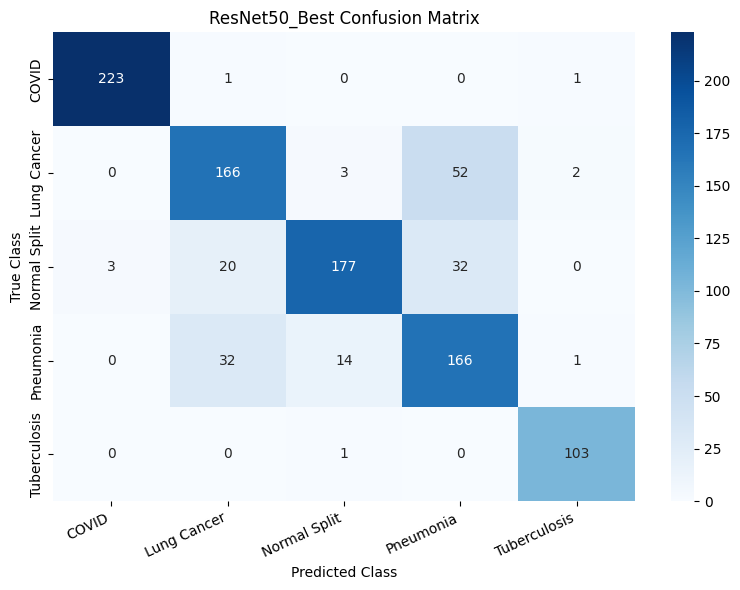

In [ ]:
CM = confusion_matrix(All_Labels, All_Preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    CM,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=Class_Names,
    yticklabels=Class_Names
)
plt.title(Model_Name + " Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_confusion_matrix.png"), dpi=300)
plt.show()




## Normalised Confusion Matrix

A normalised confusion matrix shows proportions instead of raw counts.




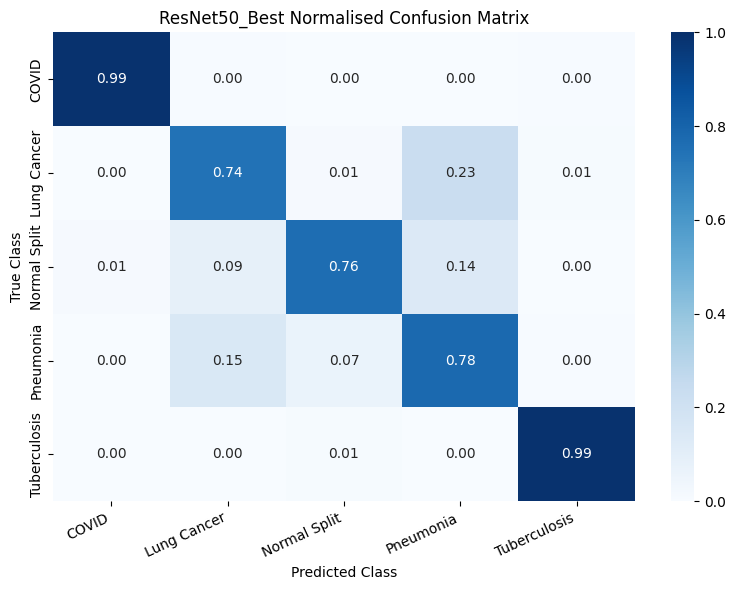

In [ ]:
CM_Normalised = CM.astype("float") / CM.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    CM_Normalised,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=Class_Names,
    yticklabels=Class_Names,
    vmin=0,
    vmax=1
)
plt.title(Model_Name + " Normalised Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_normalised_confusion_matrix.png"), dpi=300)
plt.show()




## Specificity

Recall/sensitivity tells us how many true disease cases were detected.






In [ ]:
Specificity_List = []

for Class_Index in range(Num_Classes):
    TP = CM[Class_Index, Class_Index]
    FN = CM[Class_Index, :].sum() - TP
    FP = CM[:, Class_Index].sum() - TP
    TN = CM.sum() - TP - FN - FP

    Specificity = TN / (TN + FP)
    Specificity_List.append(Specificity)

Per_Class_Metrics = Report_DF.loc[
    Class_Names,
    ["precision", "recall", "f1-score", "support"]
].copy()

Per_Class_Metrics["specificity"] = Specificity_List

display(Per_Class_Metrics)

Per_Class_Metrics.to_csv(
    os.path.join(Evaluation_Direct, Model_Name + "_per_class_metrics.csv")
)




,precision,recall,f1-score,support,specificity
COVID,0.986726,0.991111,0.988914,225.0,0.996114
Lung Cancer,0.757991,0.744395,0.751131,223.0,0.931525
Normal Split,0.907692,0.762931,0.829040,232.0,0.976471
Pneumonia,0.664000,0.779343,0.717063,213.0,0.892857
Tuberculosis,0.962617,0.990385,0.976303,104.0,0.995521


## Per-Class Metric Bar Chart

This graph compares precision, recall, specificity and F1-score for each class.





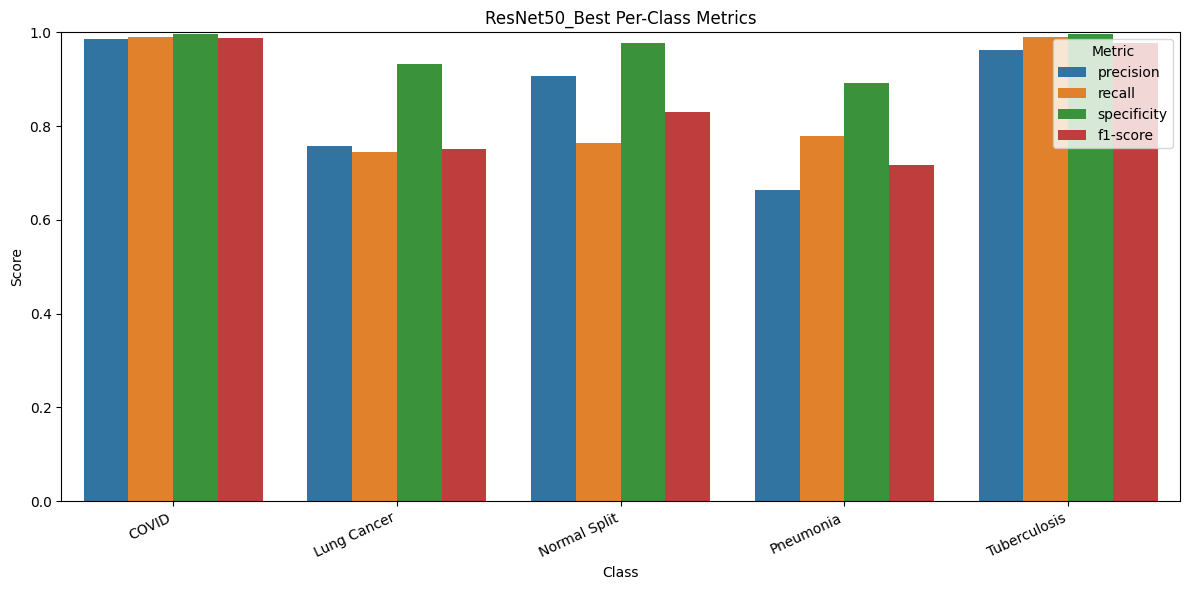

In [ ]:
Metric_Plot_DF = Per_Class_Metrics.reset_index()
Metric_Plot_DF = Metric_Plot_DF.rename(columns={"index": "Class"})

Metric_Plot_DF = Metric_Plot_DF.melt(
    id_vars="Class",
    value_vars=["precision", "recall", "specificity", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=Metric_Plot_DF, x="Class", y="Score", hue="Metric")
plt.title(Model_Name + " Per-Class Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_per_class_metrics.png"), dpi=300)
plt.show()




## ROC-AUC Scores

ROC-AUC measures how well the model separated each class from the other classes.






In [ ]:
Y_True_Binary = label_binarize(All_Labels, classes=np.arange(Num_Classes))

Roc_Auc_Rows = []

for Class_Index, Class_Name in enumerate(Class_Names):
    Roc_Auc = roc_auc_score(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    PR_Auc = average_precision_score(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    Roc_Auc_Rows.append({
        "Class": Class_Name,
        "ROC_AUC": Roc_Auc,
        "PR_AUC": PR_Auc
    })

AUC_DF = pd.DataFrame(Roc_Auc_Rows)
display(AUC_DF)

AUC_DF.to_csv(
    os.path.join(Evaluation_Direct, Model_Name + "_auc_scores.csv"),
    index=False
)

Macro_ROC_AUC = roc_auc_score(
    All_Labels,
    All_Probs,
    multi_class="ovr",
    average="macro"
)

Weighted_ROC_AUC = roc_auc_score(
    All_Labels,
    All_Probs,
    multi_class="ovr",
    average="weighted"
)

print("Macro ROC-AUC:", Macro_ROC_AUC)
print("Weighted ROC-AUC:", Weighted_ROC_AUC)




,Class,ROC_AUC,PR_AUC
0,COVID,0.999891,0.999638
1,Lung Cancer,0.948633,0.824877
2,Normal Split,0.957499,0.914052
3,Pneumonia,0.933182,0.772897
4,Tuberculosis,0.999720,0.998077


Macro ROC-AUC: 0.967785159434956
Weighted ROC-AUC: 0.9642920956084621


## ROC Curves

The ROC curve shows the relationship between sensitivity and false positive
rate for each class.




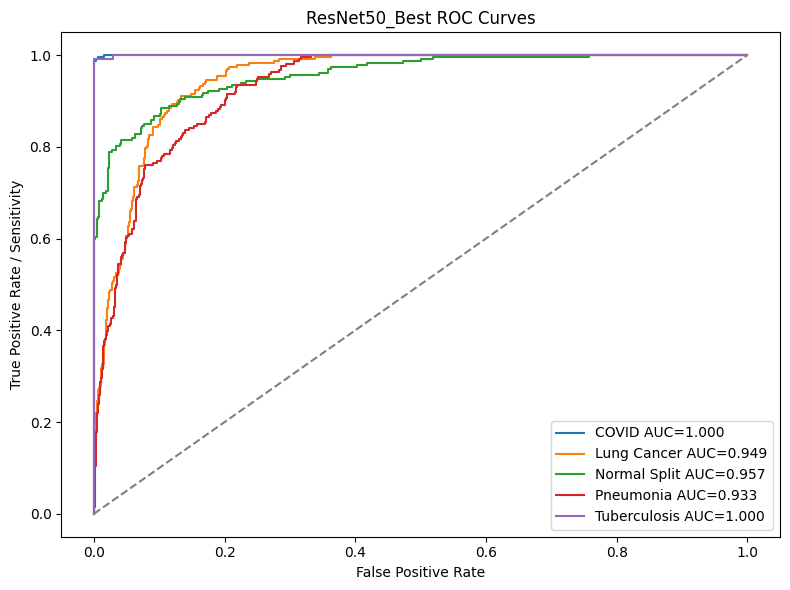

In [ ]:
plt.figure(figsize=(8, 6))

for Class_Index, Class_Name in enumerate(Class_Names):
    FPR, TPR, _ = roc_curve(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    Roc_Auc = roc_auc_score(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    plt.plot(FPR, TPR, label=f"{Class_Name} AUC={Roc_Auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title(Model_Name + " ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_roc_curves.png"), dpi=300)
plt.show()




## Precision-Recall Curves

Precision-recall curves are useful when classes are imbalanced.
They show the relationship between precision and recall for each class.




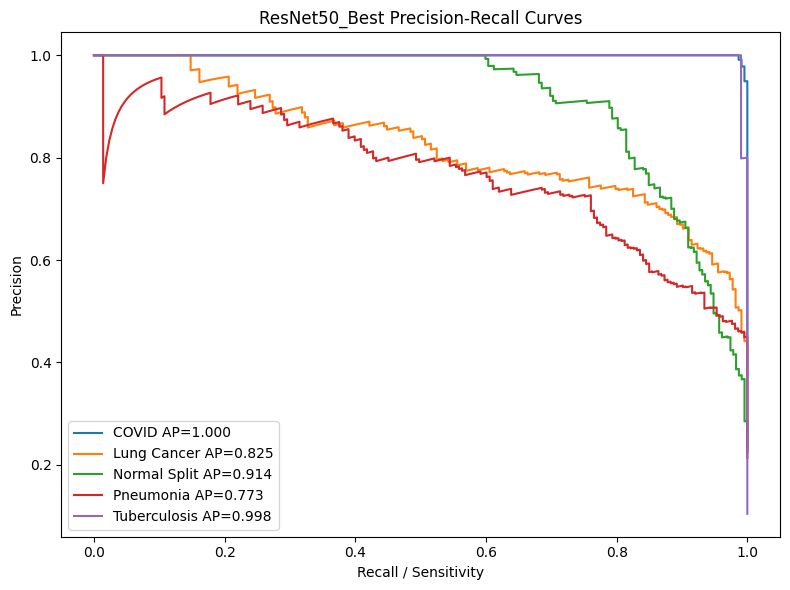

In [ ]:
plt.figure(figsize=(8, 6))

for Class_Index, Class_Name in enumerate(Class_Names):
    Precision, Recall, _ = precision_recall_curve(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    PR_Auc = average_precision_score(
        Y_True_Binary[:, Class_Index],
        All_Probs[:, Class_Index]
    )

    plt.plot(Recall, Precision, label=f"{Class_Name} AP={PR_Auc:.3f}")

plt.title(Model_Name + " Precision-Recall Curves")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_precision_recall_curves.png"), dpi=300)
plt.show()




## Prediction Confidence

This graph shows the models confidence level




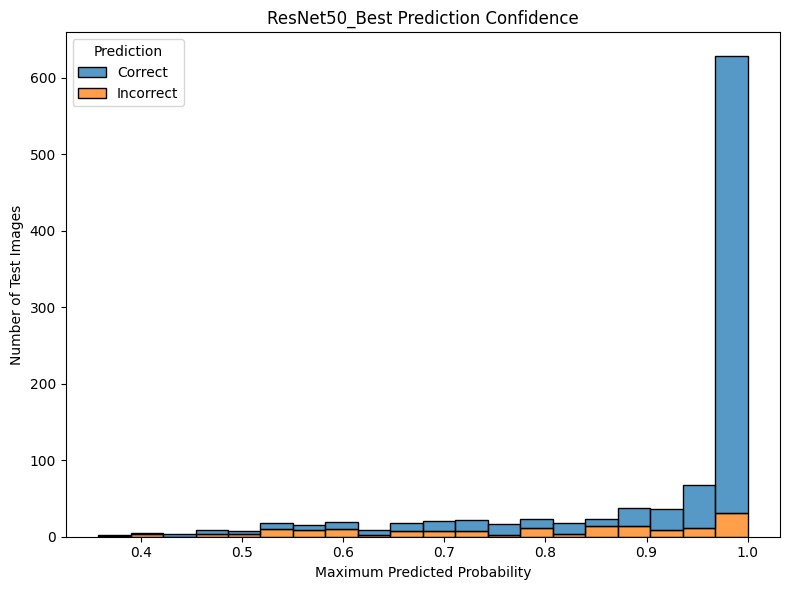

In [ ]:
Confidence = np.max(All_Probs, axis=1)
Correct = All_Labels == All_Preds

Confidence_DF = pd.DataFrame({
    "Confidence": Confidence,
    "Prediction": np.where(Correct, "Correct", "Incorrect")
})

plt.figure(figsize=(8, 6))
sns.histplot(
    data=Confidence_DF,
    x="Confidence",
    hue="Prediction",
    bins=20,
    multiple="stack"
)
plt.title(Model_Name + " Prediction Confidence")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Number of Test Images")
plt.tight_layout()
plt.savefig(os.path.join(Evaluation_Direct, Model_Name + "_confidence_histogram.png"), dpi=300)
plt.show()




## Save Individual Predictions

This CSV is useful for error analysis because it stores every test image path,
true label, predicted label and prediction confidence.




In [ ]:
Prediction_Rows = []

for Index, (Image_Path, _) in enumerate(Test_Data.samples):
    Row = {
        "Image_Path": Image_Path,
        "True_Label": Class_Names[All_Labels[Index]],
        "Predicted_Label": Class_Names[All_Preds[Index]],
        "Correct": bool(All_Labels[Index] == All_Preds[Index]),
        "Confidence": float(Confidence[Index])
    }

    for Class_Index, Class_Name in enumerate(Class_Names):
        Row["Probability_" + Class_Name] = float(All_Probs[Index, Class_Index])

    Prediction_Rows.append(Row)

Predictions_DF = pd.DataFrame(Prediction_Rows)
display(Predictions_DF.head())

Predictions_DF.to_csv(
    os.path.join(Evaluation_Direct, Model_Name + "_test_predictions.csv"),
    index=False
)




,Image_Path,True_Label,Predicted_Label,Correct,Confidence,Probability_COVID,Probability_Lung Cancer,Probability_Normal Split,Probability_Pneumonia,Probability_Tuberculosis
0,/content/chest_xray_final_eval/test/COVID/COVI...,COVID,COVID,True,0.996630,0.996630,0.000220,0.001683,0.000875,0.000593
1,/content/chest_xray_final_eval/test/COVID/COVI...,COVID,COVID,True,0.999870,0.999870,0.000006,0.000018,0.000028,0.000078
2,/content/chest_xray_final_eval/test/COVID/COVI...,COVID,COVID,True,0.991909,0.991909,0.000046,0.000361,0.000542,0.007142
3,/content/chest_xray_final_eval/test/COVID/COVI...,COVID,COVID,True,0.999481,0.999481,0.000016,0.000331,0.000085,0.000088
4,/content/chest_xray_final_eval/test/COVID/COVI...,COVID,COVID,True,0.986244,0.986244,0.000472,0.002755,0.001063,0.009465


## Summary Metrics Table

This table gives the main results that can be included in the dissertation.




In [ ]:
Summary = {
    "Model": Model_Name,
    "Accuracy": Accuracy,
    "Balanced_Accuracy": Balanced_Accuracy,
    "Macro_Precision": Report["macro avg"]["precision"],
    "Macro_Recall": Report["macro avg"]["recall"],
    "Macro_F1": Report["macro avg"]["f1-score"],
    "Weighted_Precision": Report["weighted avg"]["precision"],
    "Weighted_Recall": Report["weighted avg"]["recall"],
    "Weighted_F1": Report["weighted avg"]["f1-score"],
    "Macro_ROC_AUC": Macro_ROC_AUC,
    "Weighted_ROC_AUC": Weighted_ROC_AUC
}

Summary_DF = pd.DataFrame([Summary])
display(Summary_DF)

Summary_DF.to_csv(
    os.path.join(Evaluation_Direct, Model_Name + "_summary_metrics.csv"),
    index=False
)




,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,Macro_ROC_AUC,Weighted_ROC_AUC
0,ResNet50_Best,0.837513,0.853633,0.855805,0.853633,0.85249,0.845711,0.837513,0.839132,0.967785,0.964292


## Prepare Images for Grad-CAM

The images were normalised before being passed into the model.
For Grad-CAM display, the image has to be converted back to a visible format.




In [ ]:
def Denormalise_Image(Image_Tensor):
    Mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    Std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    Image = Image_Tensor.cpu() * Std + Mean
    Image = Image.clamp(0, 1)
    Image = Image.permute(1, 2, 0).numpy()

    return Image


if Model_Type == "densenet121":
    Target_Layers = [Model.features.denseblock4]
else:
    Target_Layers = [Model.layer4[-1]]

print("Grad-CAM target layer selected.")




Grad-CAM target layer selected.


## Choose Grad-CAM Examples

This cell selects:

- one correct prediction from each class
- up to six incorrect predictions

These examples can be used in the Results and Evaluation chapters.




In [ ]:
Correct_Indexes = []

for Class_Index in range(Num_Classes):
    Matching_Indexes = np.where(
        (All_Labels == Class_Index) & (All_Preds == Class_Index)
    )[0]

    if len(Matching_Indexes) > 0:
        Correct_Indexes.append(Matching_Indexes[0])

Incorrect_Indexes = np.where(All_Labels != All_Preds)[0]
Incorrect_Indexes = Incorrect_Indexes[:6]

print("Correct Grad-CAM examples:", Correct_Indexes)
print("Incorrect Grad-CAM examples:", Incorrect_Indexes)




Correct Grad-CAM examples: [np.int64(0), np.int64(225), np.int64(448), np.int64(680), np.int64(893)]
Incorrect Grad-CAM examples: [ 29  71 230 253 254 255]


## Function to Create Grad-CAM Figure

The heatmap is created for the predicted class.
This helps show what image area influenced the model's decision.




In [ ]:
def Create_GradCAM_Figure(Indexes, Figure_Title, Save_Name):
    if len(Indexes) == 0:
        print("No images found for:", Figure_Title)
        return

    CAM = GradCAM(
        model=Model,
        target_layers=Target_Layers
    )

    Columns = min(3, len(Indexes))
    Rows = int(np.ceil(len(Indexes) / Columns))

    plt.figure(figsize=(5 * Columns, 5 * Rows))

    for Plot_Index, Dataset_Index in enumerate(Indexes, start=1):
        Image_Tensor, _ = Test_Data[Dataset_Index]

        Input_Tensor = Image_Tensor.unsqueeze(0).to(Device)
        Predicted_Class = int(All_Preds[Dataset_Index])
        True_Class = int(All_Labels[Dataset_Index])

        Target = [ClassifierOutputTarget(Predicted_Class)]

        Grayscale_CAM = CAM(
            input_tensor=Input_Tensor,
            targets=Target
        )[0]

        RGB_Image = Denormalise_Image(Image_Tensor)
        CAM_Image = show_cam_on_image(
            RGB_Image,
            Grayscale_CAM,
            use_rgb=True
        )

        plt.subplot(Rows, Columns, Plot_Index)
        plt.imshow(CAM_Image)
        plt.axis("off")
        plt.title(
            "True: " + Class_Names[True_Class] +
            "\nPred: " + Class_Names[Predicted_Class],
            fontsize=10
        )

    plt.suptitle(Figure_Title)
    plt.tight_layout()
    plt.savefig(os.path.join(Evaluation_Direct, Save_Name), dpi=300)
    plt.show()




## Grad-CAM for Correct Predictions

These examples show whether the model focuses on relevant chest regions when
it predicts the correct class.




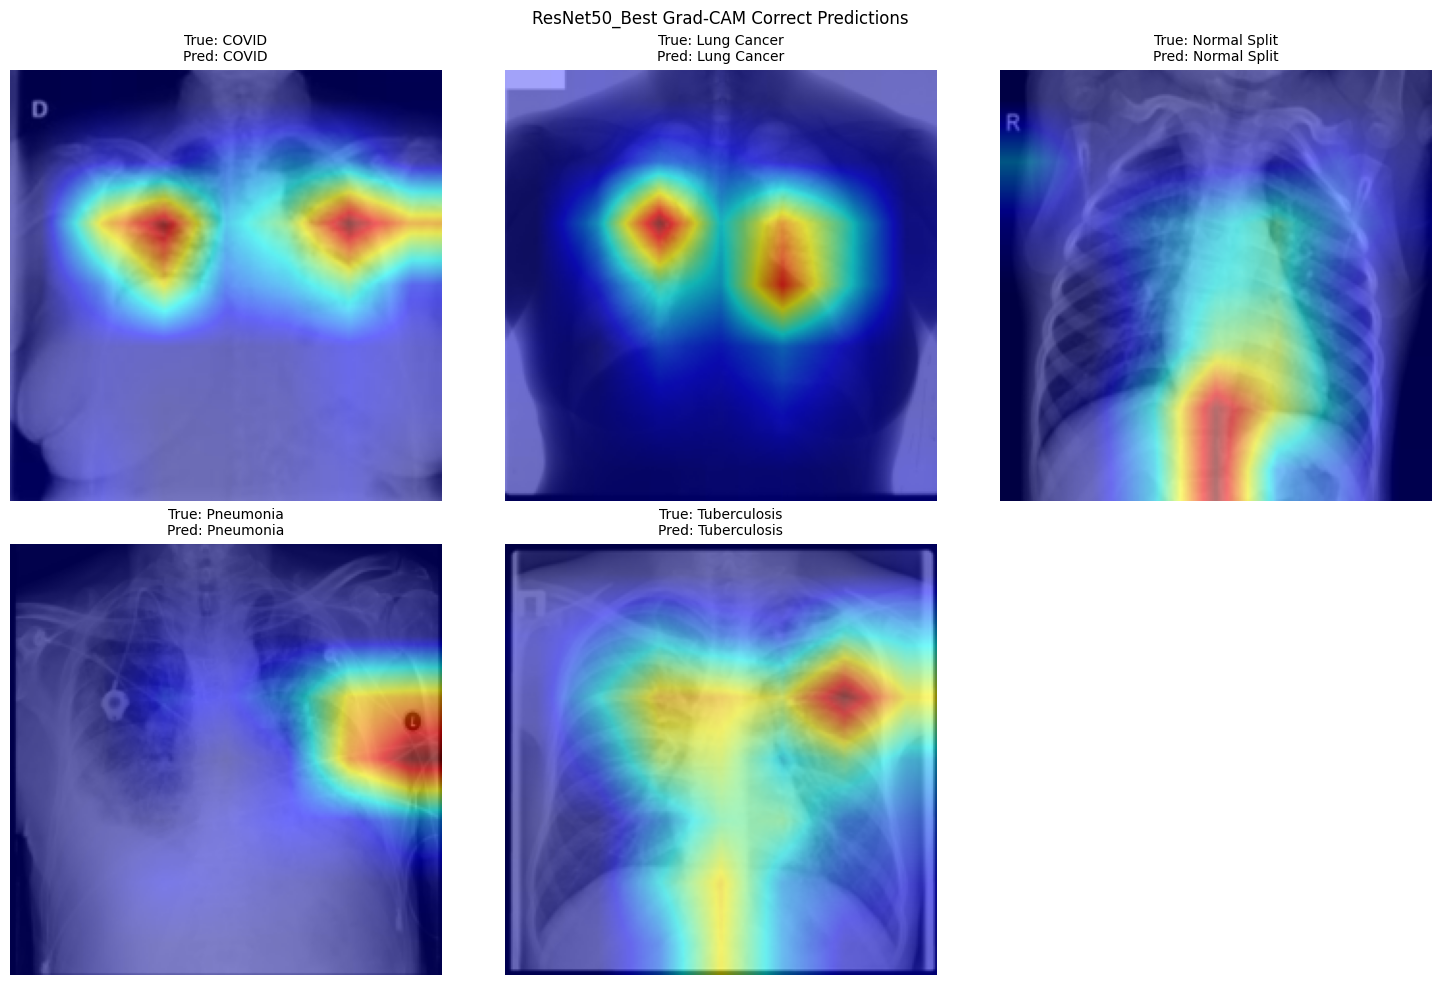

In [ ]:
Create_GradCAM_Figure(
    Correct_Indexes,
    Model_Name + " Grad-CAM Correct Predictions",
    Model_Name + "_gradcam_correct_predictions.png"
)




## Grad-CAM for Incorrect Predictions

These examples are useful for discussing model limitations.
For example, the heatmap may show that the model focused on an irrelevant
area or an image artefact.




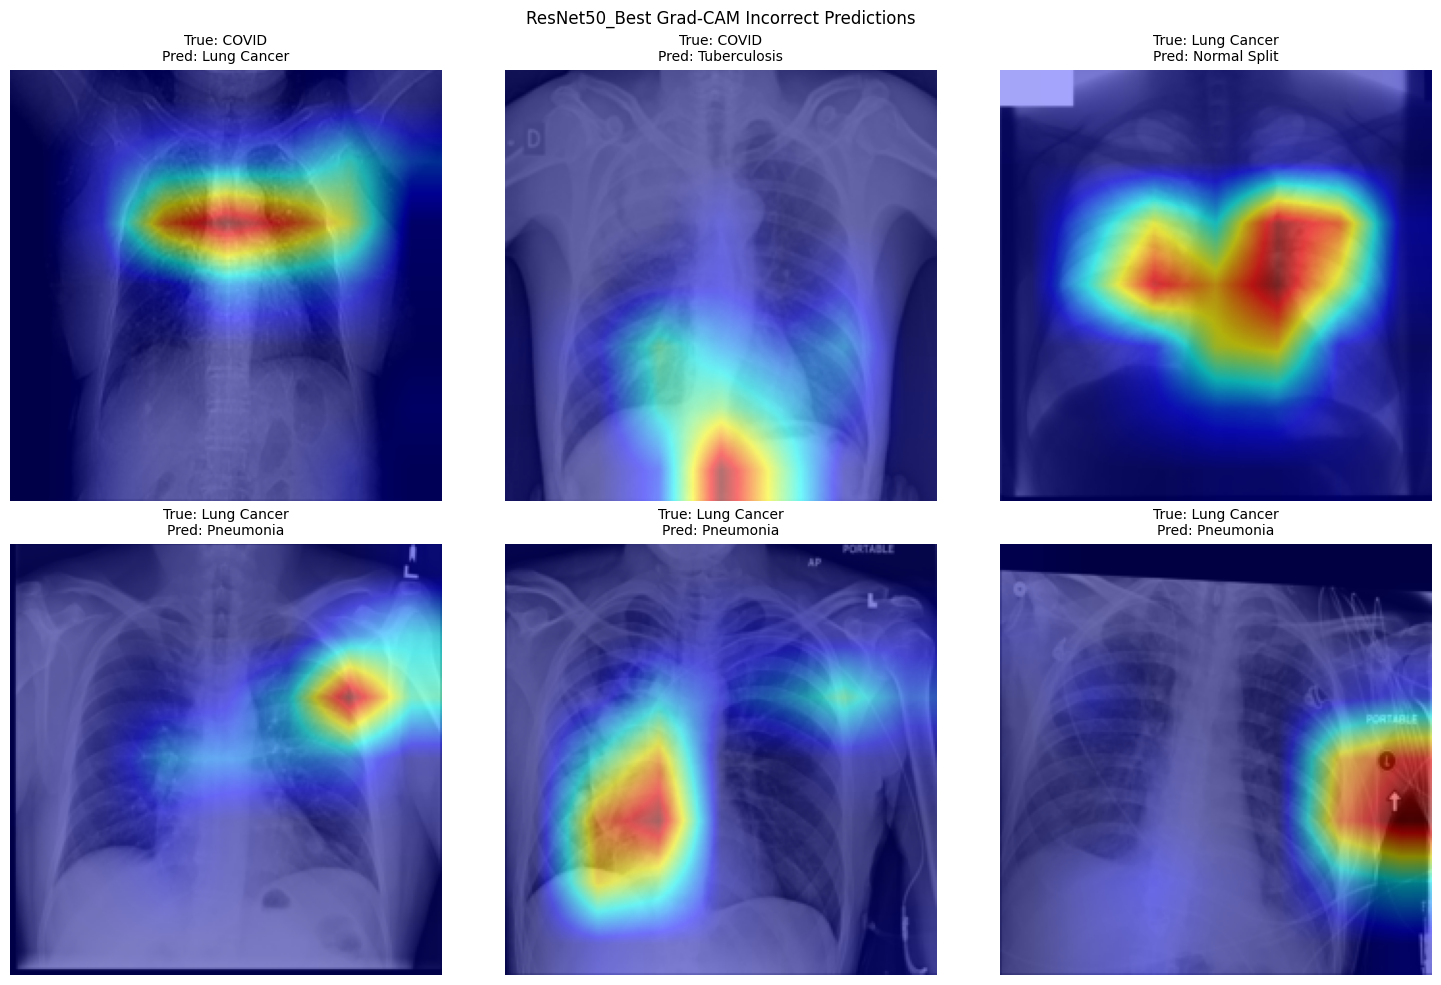

In [ ]:
Create_GradCAM_Figure(
    Incorrect_Indexes,
    Model_Name + " Grad-CAM Incorrect Predictions",
    Model_Name + "_gradcam_incorrect_predictions.png"
)


